In [1]:
import sys
sys.path.append('..')
from utils_v2_for_gfIFQ.utils_coupled_systems import *
from utils_v2_for_gfIFQ.utils_single_qubit import *


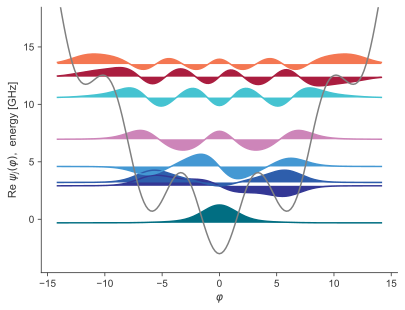

In [28]:
qbt = gfIFQ(EJ = 3,EC = 3/2, EL = 3/15,truncated_dim=8)
qbt.fluxonium.plot_wavefunction(which=[0,1,2,3,4,6,7,8])

initial_states = [
    qutip.basis(qbt.truncated_dim, 0)
]

e_ops = []
for ql in range(qbt.truncated_dim):
    e_ops.append(qutip.ket2dm(qutip.basis(qbt.truncated_dim, ql)))


In [ ]:
qbt.get_STIRAP_drive_terms(i=0,j=3,k=2,t_stop=t_stop,Rabi_freq0=Rabi_freq0)

# 2009 STIRAP is not enough:

 Total run time:   2.22s*] Elapsed 2.22s / Remaining 00:00:00:00


(1e-09, 2)

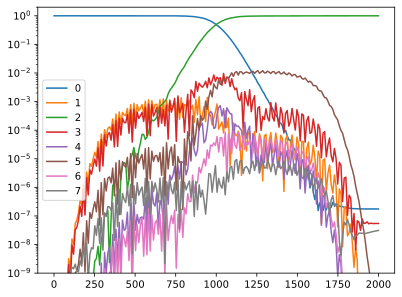

In [6]:
t_stop = 2000
Rabi_freq0 = 0.02
tlist = np.linspace(0,t_stop, 200)

results = qbt.run_qutip_mesolve_parrallel(
        initial_states=initial_states,
        tlist=tlist,
        drive_terms = qbt.get_STIRAP_drive_terms(i=0,j=3,k=2,t_stop=t_stop,Rabi_freq0=Rabi_freq0),
        c_ops = None,
        e_ops=e_ops
    )

for i in range(qbt.truncated_dim):
    plt.plot(tlist,results[0].expect[i],label= f"{i}")

plt.legend()
plt.yscale('log')
plt.ylim(1e-9,2)

 Total run time:   1.18s*] Elapsed 1.18s / Remaining 00:00:00:00


(1e-09, 2)

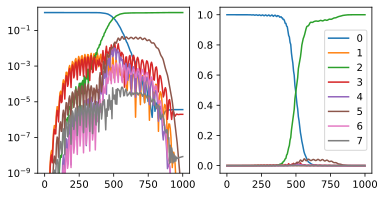

In [11]:
t_stop = 1000
Rabi_freq0 = 0.04
tlist = np.linspace(0,t_stop, 200)

results = qbt.run_qutip_mesolve_parrallel(
        initial_states=initial_states,
        tlist=tlist,
        drive_terms = qbt.get_STIRAP_drive_terms(i=0,j=3,k=2,t_stop=t_stop,Rabi_freq0=Rabi_freq0),
        c_ops = None,
        e_ops=e_ops
    )


fig, axes = plt.subplots(1,2,figsize = (6,3))
for i in range(qbt.truncated_dim):
    axes[0].plot(tlist,results[0].expect[i],label= f"{i}")
    axes[1].plot(tlist,results[0].expect[i],label= f"{i}")
axes[1].legend()
axes[0].set_yscale('log')
axes[0].set_ylim(1e-9,2)

# 

# TODO: how much does the level 5 affect fidelity? try using lower levels

 Total run time:   0.59s*] Elapsed 0.59s / Remaining 00:00:00:00


(1e-09, 2)

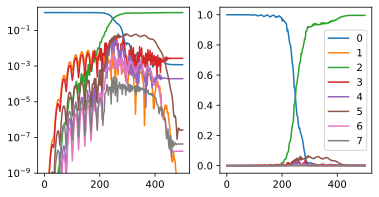

In [14]:
t_stop = 500
Rabi_freq0 = 0.05
tlist = np.linspace(0,t_stop, 200)

results = qbt.run_qutip_mesolve_parrallel(
        initial_states=initial_states,
        tlist=tlist,
        drive_terms = qbt.get_STIRAP_drive_terms(i=0,j=3,k=2,t_stop=t_stop,Rabi_freq0=Rabi_freq0),
        c_ops = None,
        e_ops=e_ops
    )


fig, axes = plt.subplots(1,2,figsize = (6,3))
for i in range(qbt.truncated_dim):
    axes[0].plot(tlist,results[0].expect[i],label= f"{i}")
    axes[1].plot(tlist,results[0].expect[i],label= f"{i}")
axes[1].legend()
axes[0].set_yscale('log')
axes[0].set_ylim(1e-9,2)

# Try some modern STIRAP

# 1: Chirping: Chirped Fractional Stimulated Raman Adiabatic Passage Jabir Chathanathil, Aneesh Ramaswamy, Vladimir S. Malinovsky, Dmitry Budker, and Svetlana A. Malinovskaya  Phys. Rev. A 108, 043710 – Published 13 October 2023